In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.utils import plot_elbow, plot_clusters, explore_dbscan_parameters
from src.Cluster import Cluster
from src.KMeans import KMeans
from src.GMM import GMM
from src.DBSCAN import DBSCAN


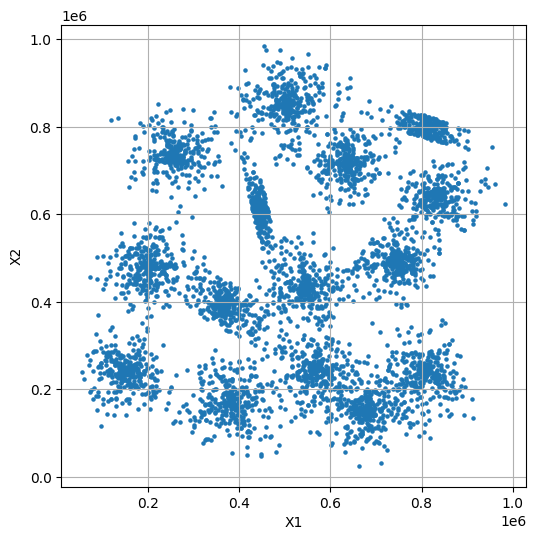

In [11]:
X = pd.read_csv('data/clustering.csv').drop(columns=['Unnamed: 0']).values

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=5)
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

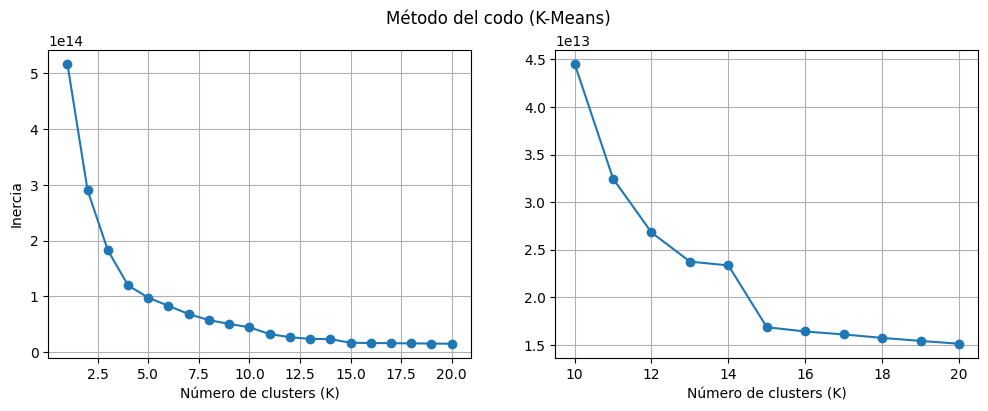

In [12]:
inertias = [kmeans(X, k)[2] for k in range(1, 21)]
plt.figure(figsize=(12, 4))
plt.suptitle("Método del codo (K-Means)")

plt.subplot(1, 2, 1)
plt.plot(range(1, 21), inertias, 'o-')
plt.ylabel("Inercia")
plt.xlabel("Número de clusters (K)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(10, 21), inertias[9:], 'o-')
plt.xlabel("Número de clusters (K)")
plt.grid(True)
plt.show()

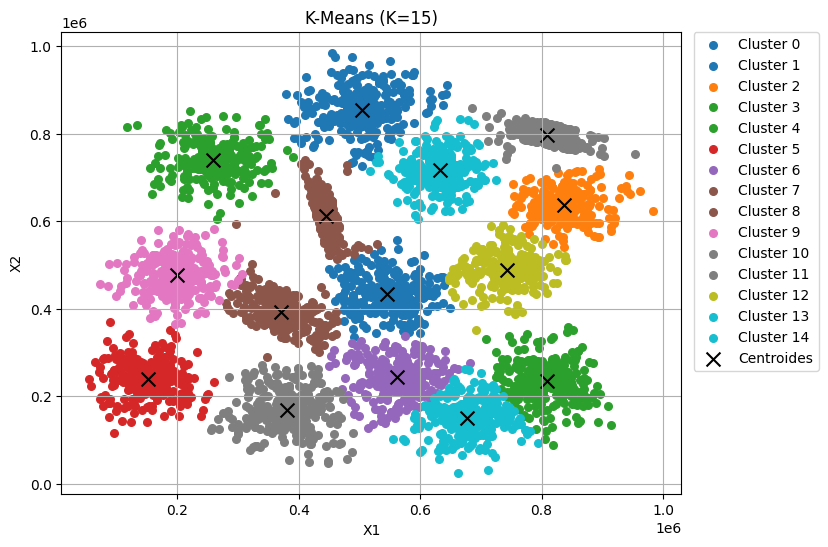

In [13]:
k_opt = 15
centroides, etiquetas_kmeans, inercia = iter_kmeans(X, k_opt, 1000, tries=200)
graficar_clusters(X, etiquetas_kmeans, centroides, titulo="K-Means (K=15)")
plt.show()

In [ ]:
X_norm = escalar_estandar(X)
inertias = []
for k in range(1, 21):
    medias, covs, pesos, etiquetas_gmm = gmm(X_norm, k)
    inertias.append(log_likelihood(X_norm, medias, covs, pesos))

plt.figure(figsize=(12, 4))
plt.suptitle("Método del codo (GMM)")

plt.subplot(1, 2, 1)
plt.plot(range(1, 21), inertias, 'o-')
plt.ylabel("Inercia")
plt.xlabel("Número de clusters (K)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(10, 21), inertias[9:], 'o-')
plt.xlabel("Número de clusters (K)")
plt.grid(True)
plt.show()

Inicializando GMM con 15 clusters...
Iteración: 79/100 [=======================================>          ] 79% - loglik: -8667.4889

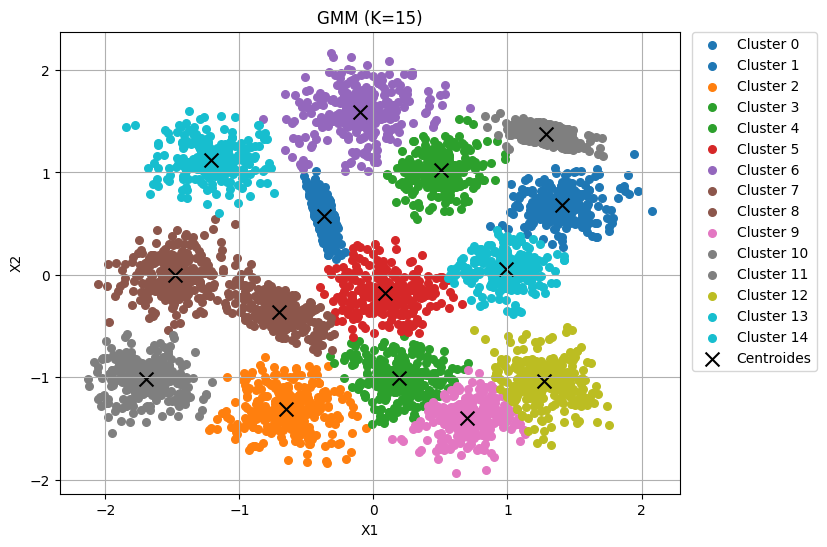

In [ ]:
medias, covs, pesos, etiquetas_gmm = gmm(X_norm, k_opt)
graficar_clusters(X_norm, etiquetas_gmm, medias, titulo=f"GMM (K={k_opt})")
plt.show()

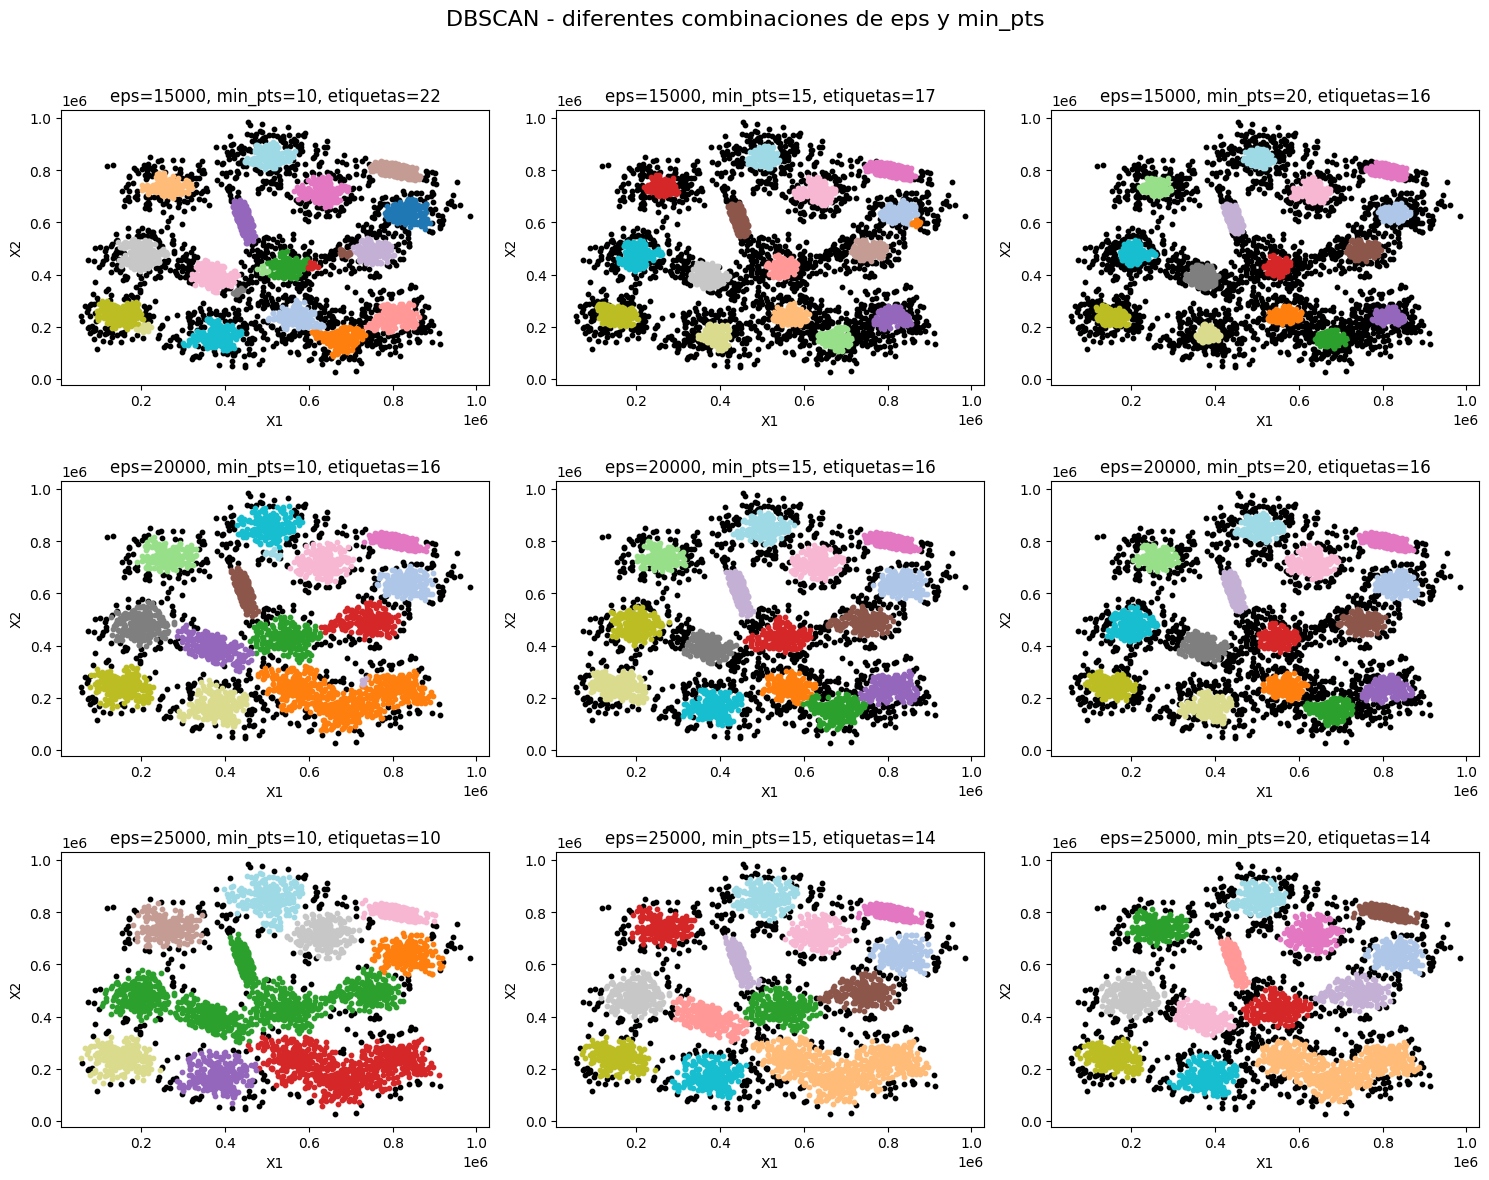

In [ ]:
# Definir valores a probar
eps_values = [15000, 20000, 25000]
min_pts_values = [10, 15, 20]

# Crear grilla de gráficos
fig, axs = plt.subplots(len(eps_values), len(min_pts_values), figsize=(15, 12))
fig.suptitle("DBSCAN - diferentes combinaciones de eps y min_pts", fontsize=16)

for i, eps in enumerate(eps_values):
    for j, min_pts in enumerate(min_pts_values):
        etiquetas = dbscan(X, eps, min_pts)
        ax = axs[i, j]
        etiquetas_unicas = np.unique(etiquetas)
        colores = plt.cm.tab20(np.linspace(0, 1, len(etiquetas_unicas)))
        for k, etiqueta in enumerate(etiquetas_unicas):
            puntos = X[etiquetas == etiqueta]
            color = 'black' if etiqueta == -1 else colores[k % len(colores)]
            ax.scatter(puntos[:, 0], puntos[:, 1], color=color, s=10)
        ax.set_title(f"eps={eps}, min_pts={min_pts}, etiquetas={len(etiquetas_unicas)}")
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Número de clusters encontrados por DBSCAN: 15


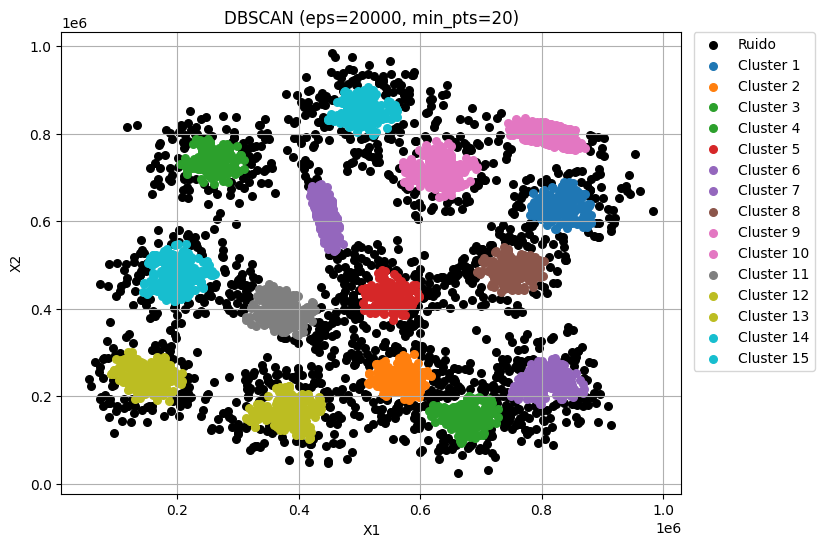

In [42]:
eps = 20000
min_pts = 20
etiquetas_dbscan = dbscan(X, eps, min_pts)
graficar_clusters(X, etiquetas_dbscan, titulo=f"DBSCAN (eps={eps}, min_pts={min_pts})")
print("Número de clusters encontrados por DBSCAN:", len(np.unique(etiquetas_dbscan)) - 1)  # -1 para excluir ruido

Número de clusters encontrados por DBSCAN (escalado): 15


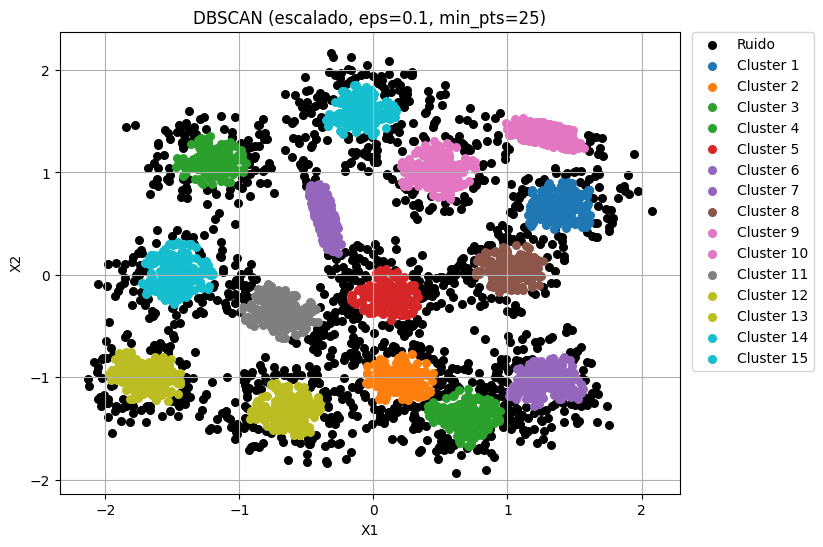

In [43]:
X_normalizado = escalar_estandar(X)  # escalado manual

eps = 0.1  # más chico ahora que los datos están escalados
min_pts = 25

etiquetas_dbscan = dbscan(X_normalizado, eps, min_pts)
graficar_clusters(X_normalizado, etiquetas_dbscan, titulo=f"DBSCAN (escalado, eps={eps}, min_pts={min_pts})")
print("Número de clusters encontrados por DBSCAN (escalado):", len(np.unique(etiquetas_dbscan)) - 1)  # -1 para excluir ruido
